In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplcursors

In [282]:
df = pd.read_csv('odds_2022-2023_v2.csv')
df = df[df['market']=='Over/Under 2.5 Goals']
df = df.drop('Unnamed: 0',axis=1)
df.head()

,Elapsed Time,Added Time,Half Time,Selection,Winning Status,Last Traded Price,Home Team,Away Team,date,market
0,0,0,0,Over 2.5 Goals,LOSER,2.20,Crystal Palace,Arsenal,2022-08-05,Over/Under 2.5 Goals
1,0,0,0,Under 2.5 Goals,WINNER,1.82,Crystal Palace,Arsenal,2022-08-05,Over/Under 2.5 Goals
2,1,0,0,Over 2.5 Goals,LOSER,2.22,Crystal Palace,Arsenal,2022-08-05,Over/Under 2.5 Goals
3,1,0,0,Under 2.5 Goals,WINNER,1.81,Crystal Palace,Arsenal,2022-08-05,Over/Under 2.5 Goals
4,3,0,0,Over 2.5 Goals,LOSER,2.28,Crystal Palace,Arsenal,2022-08-05,Over/Under 2.5 Goals


In [285]:
df_test = df[(df['Added Time']>50) ]
df_test.shape


(1231, 10)

In [193]:
goals = pd.read_csv("goals_2022-2023.csv")
#goals = goals.rename(columns={'Goal Type':'Selection'})
goals['Half Time'] = '0'
goals['Goal Scored'] = 'Yes'
goals['date'] = goals['date'].str[:10]
#goals = goals[['Elapsed Time', 'Added Time', 'Half Time', 'Selection','Home Team', 'Away Team', 'date', 'market', 'Score']]
goals.head(5)



,URL,Home Team,Away Team,date,Goal Type,Score,Player,Elapsed Time,Added Time,Half Time,Goal Scored
0,https://www.xscores.com/soccer/match/crystal-p...,Crystal Palace,Arsenal,2022-08-05,Regular goal,0-1,Gabriel Martinelli,20,0,0,Yes
1,https://www.xscores.com/soccer/match/crystal-p...,Crystal Palace,Arsenal,2022-08-05,Own goal,0-2,Marc Guehi,85,0,0,Yes
2,https://www.xscores.com/soccer/match/fulham-vs...,Fulham,Liverpool,2022-08-06,Regular goal,1-0,Aleksandar Mitrovic,32,0,0,Yes
3,https://www.xscores.com/soccer/match/fulham-vs...,Fulham,Liverpool,2022-08-06,Regular goal,1-1,Darwin Nunez,64,0,0,Yes
4,https://www.xscores.com/soccer/match/fulham-vs...,Fulham,Liverpool,2022-08-06,Penalty,2-1,Aleksandar Mitrovic,72,0,0,Yes


In [266]:

print(goals2.head())
print(new_df['time key'].head())
print(set(new_df['time key'])& set(goals2['time key']))

                                                    URL Home Team Away Team  \
1022  https://www.xscores.com/soccer/match/arsenal-v...   Arsenal  Brighton   
1023  https://www.xscores.com/soccer/match/arsenal-v...   Arsenal  Brighton   
1024  https://www.xscores.com/soccer/match/arsenal-v...   Arsenal  Brighton   

            date     Goal Type Score            Player  Elapsed Time  \
1022  2023-05-14  Regular goal   0-1      Julio Enciso            51   
1023  2023-05-14  Regular goal   0-2       Deniz Undav            86   
1024  2023-05-14  Regular goal   0-3  Pervis Estupinan            90   

      Added Time Half Time Goal Scored    time key  
1022           0         0         Yes  (51, 0, 0)  
1023           0         0         Yes  (86, 0, 0)  
1024           6         0         Yes  (90, 6, 0)  
0    (0, 0, 0)
1    (1, 0, 0)
2    (2, 0, 0)
3    (3, 0, 0)
4    (4, 0, 0)
Name: time key, dtype: object
{(86, 0, 0), (51, 0, 0)}


In [274]:
ars_cry2 = df[(df['Home Team']=='Arsenal')&(df['Away Team']=='Brighton')].copy()

norm_mins = [(x,0,0) for x in range(0,91)]
ars_cry2['time key'] = list(zip(ars_cry2['Elapsed Time'].astype(int),ars_cry2['Added Time'].astype(int),ars_cry2['Half Time'].astype(int)))
extra_times = set(ars_cry2['time key'])-set(norm_mins)
all_times = sorted(norm_mins+list(extra_times))
new_df = pd.DataFrame(all_times,columns = ['Elapsed Time','Added Time','Half Time'])
new_df['time key'] = list(zip(new_df['Elapsed Time'].astype(int),new_df['Added Time'].astype(int),new_df['Half Time'].astype(int)))

ars_cry_under = ars_cry2[ars_cry2['Selection']=='Under 2.5 Goals'].copy()
ars_cry_over = ars_cry2[ars_cry2['Selection']=='Over 2.5 Goals'].copy()

new_df = new_df.merge(ars_cry_under[['time key','Last Traded Price']],on='time key',how ='left')
new_df = new_df.rename(columns={'Last Traded Price':'Under 2.5 Odds'})
new_df['Under 2.5 Odds']=new_df['Under 2.5 Odds'].interpolate()
new_df = new_df.merge(ars_cry_over[['time key','Last Traded Price']],on='time key',how ='left')
new_df = new_df.rename(columns={'Last Traded Price':'Over 2.5 Odds'})
new_df['Over 2.5 Odds']=new_df['Over 2.5 Odds'].interpolate()


goals2 = goals[(goals['Home Team']=='Arsenal')&(goals['Away Team']=='Brighton')].copy()
goals2['time key'] = list(zip(goals2['Elapsed Time'].astype(int),goals2['Added Time'].astype(int),goals2['Half Time'].astype(int)))

new_df = new_df.merge(goals2[['time key','Goal Scored','Player','Goal Type','Score']],on='time key',how ='left')
new_df['Score']=new_df['Score'].ffill().fillna('0-0')
new_df['Goal Scored']=new_df['Goal Scored'].fillna('No')
new_df['synth under']=1/(new_df['Over 2.5 Odds']-1)+1

def format_time(row):
    if row['Half Time']>0:
        return f'HT{row['Half Time']}'
    elif row['Added Time']>0:
        return f"{row['Elapsed Time']}+{row['Added Time']}"
    else: 
        return f"{row['Elapsed Time']}"

new_df['plot label'] = new_df.apply(format_time,axis=1)

new_df.head(80)


,Elapsed Time,Added Time,Half Time,time key,Under 2.5 Odds,Over 2.5 Odds,Goal Scored,Player,Goal Type,Score,synth under,plot label
0,0,0,0,"(0, 0, 0)",NaN,1.53,No,NaN,NaN,0-0,2.886792,0
1,1,0,0,"(1, 0, 0)",NaN,1.54,No,NaN,NaN,0-0,2.851852,1
2,2,0,0,"(2, 0, 0)",2.82,1.55,No,NaN,NaN,0-0,2.818182,2
3,3,0,0,"(3, 0, 0)",2.76,1.58,No,NaN,NaN,0-0,2.724138,3
4,4,0,0,"(4, 0, 0)",2.74,1.56,No,NaN,NaN,0-0,2.785714,4
...,...,...,...,...,...,...,...,...,...,...,...,...
75,45,36,0,"(45, 36, 0)",1.78,2.30,No,NaN,NaN,0-0,1.769231,45+36
76,45,37,0,"(45, 37, 0)",1.71,2.38,No,NaN,NaN,0-0,1.724638,45+37
77,45,38,0,"(45, 38, 0)",1.63,2.60,No,NaN,NaN,0-0,1.625000,45+38
78,45,39,0,"(45, 39, 0)",1.58,2.72,No,NaN,NaN,0-0,1.581395,45+39


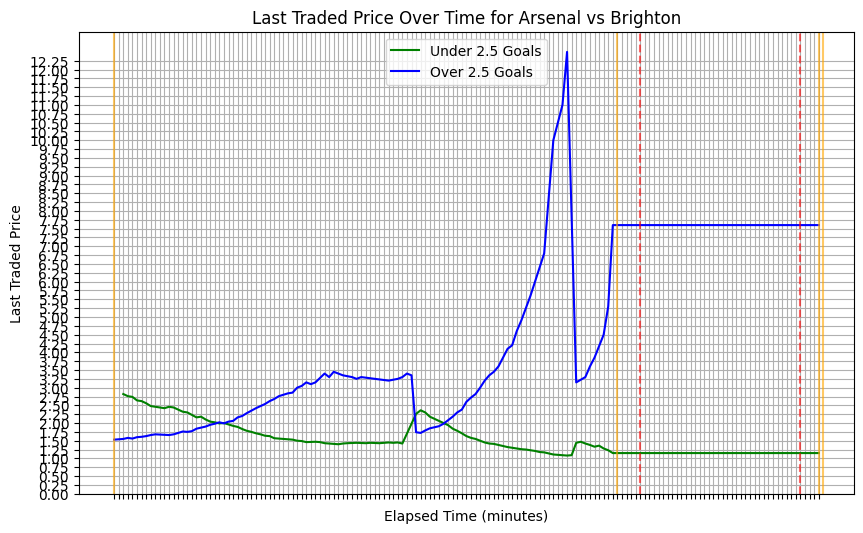

In [262]:
# Plotting the data
plt.figure(figsize=(10, 6))
plt.plot('plot label', 'Under 2.5 Odds', data =new_df ,linestyle='-', color='green', label='Under 2.5 Goals')
plt.plot('plot label', 'Over 2.5 Odds', data =new_df, linestyle='-', color='blue', label='Over 2.5 Goals')
#plt.plot('plot label', 'synth under', data =new_df, linestyle='-', color='blue', label='synth under')

y_max = max(new_df['Over 2.5 Odds'].max(),new_df['Under 2.5 Odds'].max())
y_range = np.arange(0,y_max,0.25)
plt.xticks(new_df['plot label'],'',rotation=45)
plt.yticks(y_range)
plt.grid()

goal_times = new_df[new_df['Goal Scored']=='Yes']['plot label']
for g in goal_times:
    plt.axvline(x=g,color='red',linestyle='--',alpha=0.6)
imp_times = ['0','HT1','46','90']

for g in imp_times:
    plt.axvline(x=g,color='orange',linestyle='-',alpha=0.6)
plt.xlabel('Elapsed Time (minutes)')
plt.ylabel('Last Traded Price')
plt.title('Last Traded Price Over Time for Arsenal vs Brighton')
plt.legend()
# Display the plot
plt.show()

In [109]:
df2 = pd.concat([df,goals],axis =0)
df2 = df2.sort_values(['Elapsed Time','Added Time','Half Time'],kind='stable')
df2['Half Time'] = df2['Half Time'].fillna(0)
df2.head(10)

,Elapsed Time,Added Time,Half Time,Selection,Winning Status,Last Traded Price,Home Team,Away Team,date,market,Score
0,0,0,0.0,Over 2.5 Goals,LOSER,2.20,Crystal Palace,Arsenal,2022-08-05,Over/Under 2.5 Goals,NaN
1,0,0,0.0,Under 2.5 Goals,WINNER,1.82,Crystal Palace,Arsenal,2022-08-05,Over/Under 2.5 Goals,NaN
1463,0,0,0.0,Over 2.5 Goals,WINNER,1.51,Fulham,Liverpool,2022-08-06,Over/Under 2.5 Goals,NaN
1464,0,0,0.0,Under 2.5 Goals,LOSER,2.94,Fulham,Liverpool,2022-08-06,Over/Under 2.5 Goals,NaN
2893,0,0,0.0,Over 2.5 Goals,WINNER,1.68,Tottenham,Southampton,2022-08-06,Over/Under 2.5 Goals,NaN
2894,0,0,0.0,Under 2.5 Goals,LOSER,2.46,Tottenham,Southampton,2022-08-06,Over/Under 2.5 Goals,NaN
3655,0,0,0.0,Over 2.5 Goals,LOSER,2.02,Newcastle,Nottingham Forest,2022-08-06,Over/Under 2.5 Goals,NaN
4766,0,0,0.0,Under 2.5 Goals,LOSER,2.02,Leicester,Brentford,2022-08-07,Over/Under 2.5 Goals,NaN
5835,0,0,0.0,Under 2.5 Goals,LOSER,2.04,Leeds,Wolverhampton,2022-08-06,Over/Under 2.5 Goals,NaN
7618,0,0,0.0,Under 2.5 Goals,WINNER,1.83,Everton,Chelsea,2022-08-06,Over/Under 2.5 Goals,NaN


In [253]:
ars_cry = df2[(df2['Home Team']=='Arsenal')&(df2['Away Team']=='Crystal Palace')].copy()
ars_cry['Score'] = ars_cry['Score'].ffill().fillna('0-0')
ars_cry['sort key'] = list(zip(ars_cry['Elapsed Time'],ars_cry['Added Time'],ars_cry['Half Time']))
ars_cry = ars_cry.sort_values('sort key').reset_index(drop=True)
ars_cry['closed'] = (ars_cry['Score'].str[0].astype(int)+ars_cry['Score'].str[-1].astype(int)>2.5)
ars_cry['index']=ars_cry.index

def format_time(row):
    if row['Half Time']>0:
        return 'HT'
    elif row['Added Time']>0:
        return f"{row['Elapsed Time']}+{row['Added Time']}"
    else: 
        return f"{row['Elapsed Time']}"
ars_cry['plot label'] = ars_cry.apply(format_time,axis=1)
ars_cry.tail()


,Elapsed Time,Added Time,Half Time,Selection,Winning Status,Last Traded Price,Home Team,Away Team,date,market,Score,sort key,closed,index,plot label
121,54,0,0.0,Over 2.5 Goals,WINNER,1.29,Arsenal,Crystal Palace,2023-03-19,Over/Under 2.5 Goals,2-0,"(54, 0, 0.0)",False,121,54
122,55,0,0.0,Under 2.5 Goals,LOSER,4.40,Arsenal,Crystal Palace,2023-03-19,Over/Under 2.5 Goals,2-0,"(55, 0, 0.0)",False,122,55
123,55,0,0.0,Regular goal,NaN,NaN,Arsenal,Crystal Palace,2023-03-19,Goal,3-0,"(55, 0, 0.0)",True,123,55
124,63,0,0.0,Regular goal,NaN,NaN,Arsenal,Crystal Palace,2023-03-19,Goal,3-1,"(63, 0, 0.0)",True,124,63
125,74,0,0.0,Regular goal,NaN,NaN,Arsenal,Crystal Palace,2023-03-19,Goal,4-1,"(74, 0, 0.0)",True,125,74


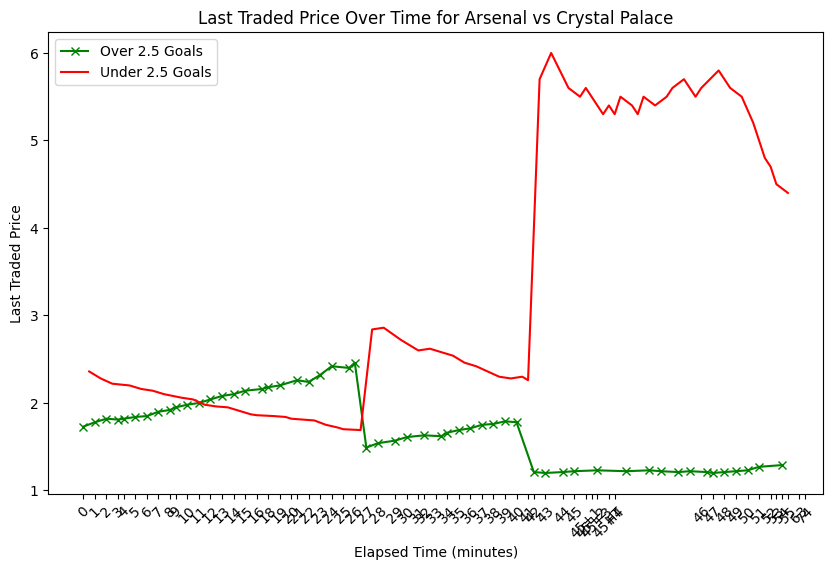

In [139]:

# Plotting the data
plt.figure(figsize=(10, 6))
plt.plot('index', 'Last Traded Price', data =ars_cry[ars_cry['Selection'] == "Over 2.5 Goals"],marker = 'x' ,linestyle='-', color='green', label='Over 2.5 Goals')
plt.plot('index', 'Last Traded Price', data=ars_cry[ars_cry['Selection'] == "Under 2.5 Goals"], linestyle='-', color='red', label='Under 2.5 Goals')

unique_labels = ars_cry['plot label'].unique()
tick_locs = [ars_cry[ars_cry['plot label']==label].index[0] for label in unique_labels]
plt.xticks(tick_locs,unique_labels,rotation=45)


# Adding labels and title

plt.xlabel('Elapsed Time (minutes)')
plt.ylabel('Last Traded Price')
plt.title('Last Traded Price Over Time for Arsenal vs Crystal Palace')
plt.legend()
# Display the plot
plt.show()


In [64]:
cry_ars[cry_ars['market']=='Goal'].head()

,Elapsed Time,Added Time,Selection,Last Traded Price,Home Team,Away Team,date,market,Score
0,20,0,Regular goal,NaN,Crystal Palace,Arsenal,2022-08-05,Goal,0-1
1,85,0,Own goal,NaN,Crystal Palace,Arsenal,2022-08-05,Goal,0-2


In [288]:
#generalised function (input home and away team, then it spits out graph)
def match_df(home,away):
    match_odds = df[(df['Home Team']==home)&(df['Away Team']==away)].copy()

    norm_mins = [(x,0,0) for x in range(0,91)]
    match_odds['time key'] = list(zip(match_odds['Elapsed Time'].astype(int),match_odds['Added Time'].astype(int),match_odds['Half Time'].astype(int)))
    extra_times = set(match_odds['time key'])-set(norm_mins)
    all_times = sorted(norm_mins+list(extra_times))
    new_df = pd.DataFrame(all_times,columns = ['Elapsed Time','Added Time','Half Time'])
    new_df['time key'] = list(zip(new_df['Elapsed Time'].astype(int),new_df['Added Time'].astype(int),new_df['Half Time'].astype(int)))

    under = match_odds[match_odds['Selection']=='Under 2.5 Goals'].copy()
    over = match_odds[match_odds['Selection']=='Over 2.5 Goals'].copy()

    new_df = new_df.merge(under[['time key','Last Traded Price']],on='time key',how ='left')
    new_df = new_df.rename(columns={'Last Traded Price':'Under 2.5 Odds'})
    new_df['Under 2.5 Odds']=new_df['Under 2.5 Odds'].interpolate()
    new_df = new_df.merge(over[['time key','Last Traded Price']],on='time key',how ='left')
    new_df = new_df.rename(columns={'Last Traded Price':'Over 2.5 Odds'})
    new_df['Over 2.5 Odds']=new_df['Over 2.5 Odds'].interpolate()


    goals2 = goals[(goals['Home Team']==home)&(goals['Away Team']==away)].copy()
    goals2['time key'] = list(zip(goals2['Elapsed Time'].astype(int),goals2['Added Time'].astype(int),goals2['Half Time'].astype(int)))

    new_df = new_df.merge(goals2[['time key','Goal Scored','Player','Goal Type','Score']],on='time key',how ='left')
    new_df['Score']=new_df['Score'].ffill().fillna('0-0')
    new_df['Goal Scored']=new_df['Goal Scored'].fillna('No')
    new_df['synth under']=1/(new_df['Over 2.5 Odds']-1)+1

    def format_time(row):
        if row['Half Time']>0:
            return f'HT{row['Half Time']}'
        elif row['Added Time']>0:
            return f"{row['Elapsed Time']}+{row['Added Time']}"
        else: 
            return f"{row['Elapsed Time']}"

    new_df['plot label'] = new_df.apply(format_time,axis=1)
    
    
    return new_df
def plot_odds(new_df,home,away):
    plt.figure(figsize=(10, 6))
    plt.plot('plot label', 'Under 2.5 Odds', data =new_df ,linestyle='-', color='green', label='Under 2.5 Goals')
    plt.plot('plot label', 'Over 2.5 Odds', data =new_df, linestyle='-', color='blue', label='Over 2.5 Goals')
    #plt.plot('plot label', 'synth under', data =new_df, linestyle='-', color='blue', label='synth under')

    y_max = max(new_df['Over 2.5 Odds'].max(),new_df['Under 2.5 Odds'].max())
    #y_range = np.arange(0,y_max,y_max//20)
    plt.xticks(new_df['plot label'],rotation=45)
    #plt.yticks(y_range)
    plt.grid()

    goal_times = new_df[new_df['Goal Scored']=='Yes']['plot label']
    for g in goal_times:
        plt.axvline(x=g,color='red',linestyle='--',alpha=0.6)
    imp_times = ['0','HT1','46','90']

    for g in imp_times:
        plt.axvline(x=g,color='orange',linestyle='-',alpha=0.6)
    plt.xlabel('Elapsed Time (minutes)')
    plt.ylabel('Last Traded Price')
    plt.title(f'Last Traded Price Over Time for {home} vs {away}')
    plt.legend()
    
   
def generate_graphs(teams):
    for home in teams:
        for away in teams:
            if home == away:
                continue
            plot_odds(match_df(home,away),home,away)
    plt.show()

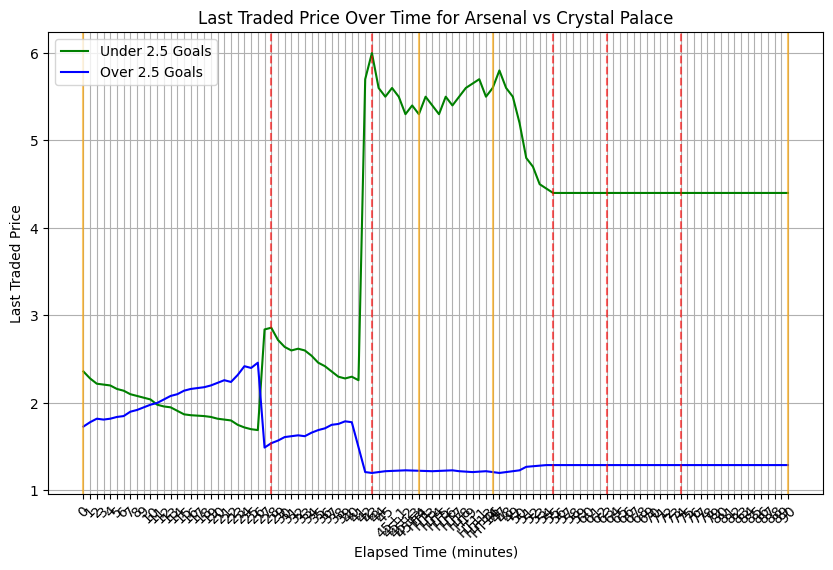

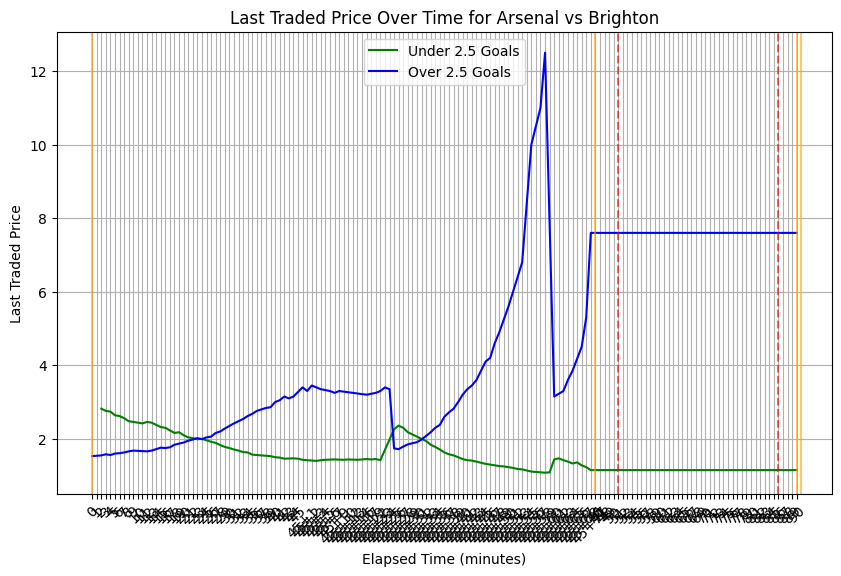

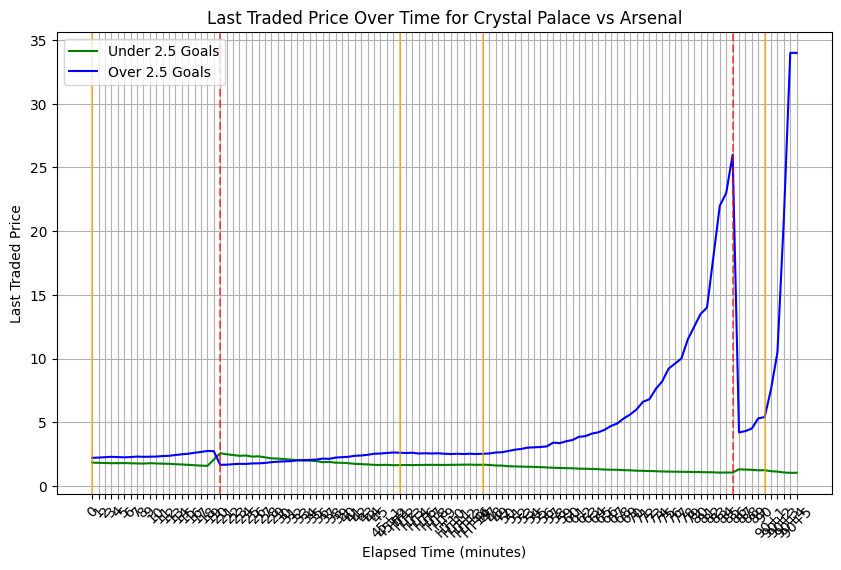

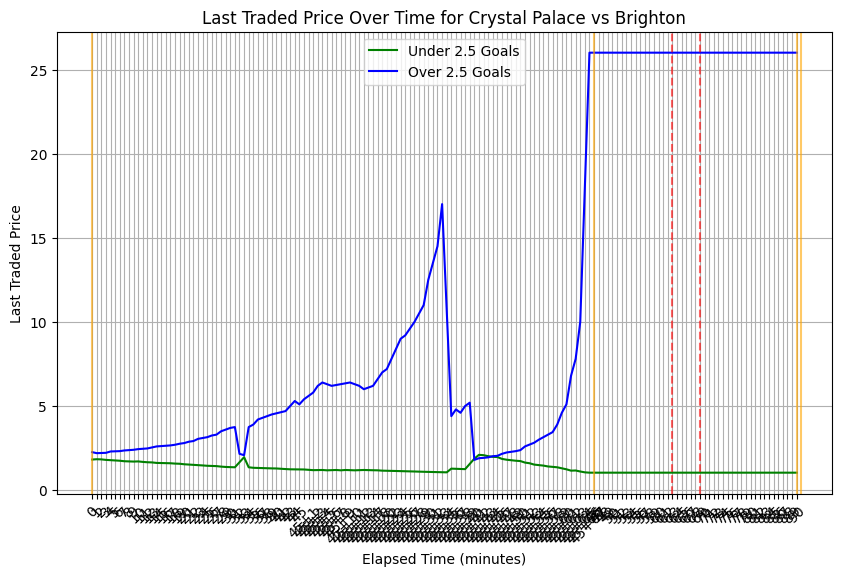

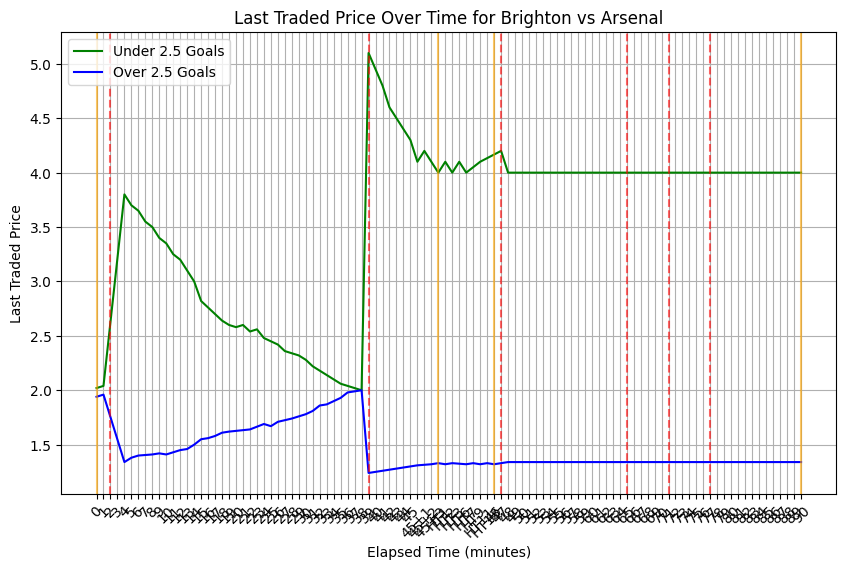

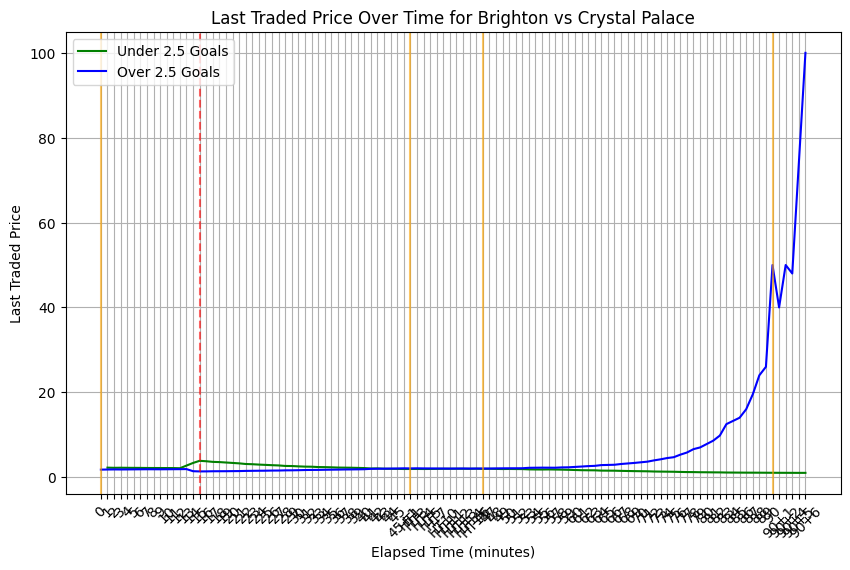

In [289]:
teams = ['Arsenal','Crystal Palace','Brighton']
generate_graphs(teams)